In [ ]:
# ═══════════════════════════════════════════════
# CELL 1 — Cài đặt & Import
# ═══════════════════════════════════════════════
!pip install -q timm scikit-learn seaborn

import os, zipfile, shutil, time, collections
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)
from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [ ]:
# ═══════════════════════════════════════════════
# CELL 2 — Nạp dataset
# ═══════════════════════════════════════════════
# *** SỬA đường dẫn cho đúng với Drive của bạn ***
DRIVE_ZIP = '/content/drive/MyDrive/combined_4class.zip'
DATASET   = '/content/combined_4class'
SAVE_DIR  = '/content/drive/MyDrive/models/compare'
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copy(DRIVE_ZIP, 'combined_4class.zip')
with zipfile.ZipFile('combined_4class.zip', 'r') as z:
    z.extractall('/content')

CLASS_NAMES = sorted(os.listdir(f'{DATASET}/train'))
N_CLASSES   = len(CLASS_NAMES)
print('Classes:', CLASS_NAMES)
print()
print(f"{'Lớp':15s} {'Train':>7} {'Val':>7} {'Test':>7}")
print('-'*40)
for cls in CLASS_NAMES:
    tr = len(os.listdir(f'{DATASET}/train/{cls}'))
    va = len(os.listdir(f'{DATASET}/val/{cls}'))
    te = len(os.listdir(f'{DATASET}/test/{cls}'))
    print(f'{cls:15s} {tr:>7} {va:>7} {te:>7}')

Classes: ['eyes_closed', 'eyes_open', 'no_yawn', 'yawn']

Lớp               Train     Val    Test
----------------------------------------
eyes_closed        2253     621     348
eyes_open          2176     524     261
no_yawn            1813     518     260
yawn               1769     505     254


In [ ]:
# ═══════════════════════════════════════════════
# CELL 3 — Cấu hình & Hàm tiện ích
# ═══════════════════════════════════════════════
SEED          = 42
BATCH_CNN     = 64
BATCH_RT      = 32
IMG_CNN       = 64
IMG_RT        = 224
EPOCHS        = 50
PATIENCE_ES   = 7
PATIENCE_LR   = 3
LR_CNN        = 1e-3
LR_RT_HEAD    = 1e-3
LR_RT_FULL    = 2e-4
PHASE1_EPOCHS = 5

torch.manual_seed(SEED)
np.random.seed(SEED)

MEAN_IN = [0.485, 0.456, 0.406]
STD_IN  = [0.229, 0.224, 0.225]

def make_loaders(img_size, batch, imagenet_norm=False):
    norm = transforms.Normalize(MEAN_IN, STD_IN) if imagenet_norm \
           else transforms.Normalize([0.5]*3, [0.5]*3)
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ToTensor(), norm,
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(), norm,
    ])
    tr = DataLoader(datasets.ImageFolder(f'{DATASET}/train', train_tf),
                    batch_size=batch, shuffle=True,  num_workers=2, pin_memory=True)
    va = DataLoader(datasets.ImageFolder(f'{DATASET}/val',   eval_tf),
                    batch_size=batch, shuffle=False, num_workers=2, pin_memory=True)
    te = DataLoader(datasets.ImageFolder(f'{DATASET}/test',  eval_tf),
                    batch_size=batch, shuffle=False, num_workers=2, pin_memory=True)
    return tr, va, te

def get_class_weights(loader):
    counts = collections.Counter([l for _, l in loader.dataset.samples])
    total  = sum(counts.values())
    w = []
    for cls in CLASS_NAMES:
        idx  = loader.dataset.class_to_idx[cls]
        base = total / (N_CLASSES * counts[idx])
        if cls == 'eyes_closed': base *= 1.5
        if cls == 'yawn':        base *= 1.2
        w.append(base)
    return torch.tensor(w, dtype=torch.float32).to(device)

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.cuda.amp.autocast():
            out  = model(imgs)
            loss = criterion(out, labels)
        loss_sum += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for imgs, labels in loader:
        out = model(imgs.to(device)).argmax(1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(out)
    return np.array(y_true), np.array(y_pred)

def run_training(model, train_loader, val_loader, optimizer, criterion,
                 epochs, save_path, label):
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5,
        patience=PATIENCE_LR, min_lr=1e-7)
    scaler = torch.cuda.amp.GradScaler()
    history = {'train_acc':[], 'val_acc':[], 'train_loss':[], 'val_loss':[]}
    best_acc, no_improve = 0.0, 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        va_loss, va_acc = eval_epoch(model, val_loader, criterion)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        scheduler.step(va_acc)
        lr_now = optimizer.param_groups[0]['lr']
        mark = ''
        if va_acc > best_acc:
            best_acc = va_acc; no_improve = 0
            torch.save(model.state_dict(), save_path)
            mark = ' ✓ best'
        else:
            no_improve += 1
        print(f'[{label}] Ep {epoch:2d} | train={tr_acc:.4f} val={va_acc:.4f} '
              f'loss={va_loss:.4f} lr={lr_now:.1e} ({time.time()-t0:.0f}s){mark}')
        if no_improve >= PATIENCE_ES:
            print(f'>> EarlyStopping ep={epoch}, best={best_acc:.4f}')
            break

    model.load_state_dict(torch.load(save_path))
    return history

print('Setup xong ✓')

Setup xong ✓


In [ ]:
# ═══════════════════════════════════════════════
# CELL 4 — Định nghĩa & Train CNN
# ═══════════════════════════════════════════════
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, drop=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(drop),
        )
    def forward(self, x): return self.block(x)

class CustomCNN(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock( 3,  32, drop=0.25),
            ConvBlock(32,  64, drop=0.25),
            ConvBlock(64, 128, drop=0.30),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, 256), nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(128, n_classes),
        )
    def forward(self, x): return self.head(self.features(x))

# Tạo model + dataloader
model_cnn    = CustomCNN(N_CLASSES).to(device)
train_cnn, val_cnn, test_cnn = make_loaders(IMG_CNN, BATCH_CNN, imagenet_norm=False)
cw_cnn       = get_class_weights(train_cnn)
crit_cnn     = nn.CrossEntropyLoss(weight=cw_cnn)
opt_cnn      = optim.Adam(model_cnn.parameters(), lr=LR_CNN, weight_decay=1e-4)
n_params_cnn = sum(p.numel() for p in model_cnn.parameters())
print(f'CNN — tham số: {n_params_cnn:,}')

# Train
print('='*60)
hist_cnn = run_training(model_cnn, train_cnn, val_cnn, opt_cnn, crit_cnn,
                        EPOCHS, f'{SAVE_DIR}/best_cnn.pt', 'CNN')

CNN — tham số: 354,404


/tmp/ipykernel_572/2381147954.py:103: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_572/2381147954.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_572/2381147954.py:80: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[CNN] Ep  1 | train=0.5800 val=0.6536 loss=0.6036 lr=1.0e-03 (14s) ✓ best
[CNN] Ep  2 | train=0.6415 val=0.6873 loss=0.5481 lr=1.0e-03 (12s) ✓ best
[CNN] Ep  3 | train=0.6612 val=0.7108 loss=0.4938 lr=1.0e-03 (11s) ✓ best
[CNN] Ep  4 | train=0.6710 val=0.7205 loss=0.4712 lr=1.0e-03 (12s) ✓ best
[CNN] Ep  5 | train=0.6869 val=0.7269 loss=0.4646 lr=1.0e-03 (12s) ✓ best
[CNN] Ep  6 | train=0.6859 val=0.7311 loss=0.4535 lr=1.0e-03 (12s) ✓ best
[CNN] Ep  7 | train=0.7030 val=0.7458 loss=0.4433 lr=1.0e-03 (13s) ✓ best
[CNN] Ep  8 | train=0.7141 val=0.7269 loss=0.4584 lr=1.0e-03 (14s)
[CNN] Ep  9 | train=0.7246 val=0.7634 loss=0.4063 lr=1.0e-03 (11s) ✓ best
[CNN] Ep 10 | train=0.7636 val=0.9036 loss=0.3249 lr=1.0e-03 (12s) ✓ best
[CNN] Ep 11 | train=0.8069 val=0.8976 loss=0.2768 lr=1.0e-03 (12s)
[CNN] Ep 12 | train=0.8378 val=0.8875 loss=0.2843 lr=1.0e-03 (13s)
[CNN] Ep 13 | train=0.8668 val=0.8925 loss=0.2968 lr=1.0e-03 (12s)
[CNN] Ep 14 | train=0.8885 val=0.9165 loss=0.2353 lr=1.0e-03 (10s)

In [ ]:
# ═══════════════════════════════════════════════
# CELL 5 — Đánh giá CNN
# ═══════════════════════════════════════════════
y_true_cnn, y_pred_cnn = predict_all(model_cnn, test_cnn)
acc_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
p_cnn, r_cnn, f1_cnn, _ = precision_recall_fscore_support(
    y_true_cnn, y_pred_cnn, average=None, labels=range(N_CLASSES))

print(f'CNN Test Accuracy: {acc_cnn:.4f}')
print(classification_report(y_true_cnn, y_pred_cnn,
                             target_names=CLASS_NAMES, digits=4))

CNN Test Accuracy: 0.9484
              precision    recall  f1-score   support

 eyes_closed     0.8912    0.9885    0.9373       348
   eyes_open     0.9821    0.8429    0.9072       261
     no_yawn     0.9696    0.9808    0.9751       260
        yawn     0.9840    0.9685    0.9762       254

    accuracy                         0.9484      1123
   macro avg     0.9567    0.9452    0.9490      1123
weighted avg     0.9515    0.9484    0.9479      1123



In [ ]:
# ═══════════════════════════════════════════════
# CELL 6 — Định nghĩa & Train RT-DETR Backbone
# ═══════════════════════════════════════════════
torch.cuda.empty_cache()

class RTDETRClassifier(nn.Module):
    def __init__(self, backbone='hgnetv2_b4', n_classes=4, drop=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            backbone, pretrained=True, num_classes=0, global_pool='avg')
        feat = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Linear(feat, 512), nn.BatchNorm1d(512),
            nn.ReLU(inplace=True), nn.Dropout(drop),
            nn.Linear(512, 128), nn.BatchNorm1d(128),
            nn.ReLU(inplace=True), nn.Dropout(drop/2),
            nn.Linear(128, n_classes),
        )
        print(f'Backbone: {backbone} | feat_dim={feat}')
    def forward(self, x):   return self.head(self.backbone(x))
    def freeze(self):       [p.__setattr__('requires_grad', False) for p in self.backbone.parameters()]
    def unfreeze(self):     [p.__setattr__('requires_grad', True)  for p in self.backbone.parameters()]

model_rt    = RTDETRClassifier('hgnetv2_b4', N_CLASSES).to(device)
n_params_rt = sum(p.numel() for p in model_rt.parameters())
train_rt, val_rt, test_rt = make_loaders(IMG_RT, BATCH_RT, imagenet_norm=True)
cw_rt    = get_class_weights(train_rt)
crit_rt  = nn.CrossEntropyLoss(weight=cw_rt)
print(f'RT-DETR — tham số: {n_params_rt:,}')

# Giai đoạn 1: freeze backbone
print('='*60)
print(f'Giai đoạn 1: Train head ({PHASE1_EPOCHS} epoch, backbone frozen)')
model_rt.freeze()
opt1    = optim.Adam(filter(lambda p: p.requires_grad, model_rt.parameters()),
                     lr=LR_RT_HEAD, weight_decay=1e-4)
scaler1 = torch.cuda.amp.GradScaler()
for ep in range(1, PHASE1_EPOCHS + 1):
    trl, tra = train_one_epoch(model_rt, train_rt, crit_rt, opt1, scaler1)
    vl,  va  = eval_epoch(model_rt, val_rt, crit_rt)
    print(f'  Epoch {ep}/{PHASE1_EPOCHS} | train={tra:.4f} val={va:.4f}')

# Giai đoạn 2: unfreeze + fine-tune
print()
print('='*60)
print('Giai đoạn 2: Fine-tune toàn bộ')
model_rt.unfreeze()
opt2 = optim.AdamW(model_rt.parameters(), lr=LR_RT_FULL, weight_decay=1e-4)
hist_rt = run_training(model_rt, train_rt, val_rt, opt2, crit_rt,
                       EPOCHS, f'{SAVE_DIR}/best_rtdetr.pt', 'RTDETR')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/79.4M [00:00<?, ?B/s]

Backbone: hgnetv2_b4 | feat_dim=2048
RT-DETR — tham số: 18,864,228
Giai đoạn 1: Train head (5 epoch, backbone frozen)


/tmp/ipykernel_572/3726224927.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler1 = torch.cuda.amp.GradScaler()
/tmp/ipykernel_572/2381147954.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_572/2381147954.py:80: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Epoch 1/5 | train=0.8513 val=0.8529
  Epoch 2/5 | train=0.8753 val=0.8778
  Epoch 3/5 | train=0.8860 val=0.8409
  Epoch 4/5 | train=0.8897 val=0.8538
  Epoch 5/5 | train=0.8928 val=0.8768

Giai đoạn 2: Fine-tune toàn bộ


/tmp/ipykernel_572/2381147954.py:103: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


[RTDETR] Ep  1 | train=0.9476 val=0.9613 loss=0.1113 lr=2.0e-04 (52s) ✓ best
[RTDETR] Ep  2 | train=0.9685 val=0.9497 loss=0.1248 lr=2.0e-04 (54s)
[RTDETR] Ep  3 | train=0.9699 val=0.9613 loss=0.1072 lr=2.0e-04 (48s)
[RTDETR] Ep  4 | train=0.9785 val=0.9631 loss=0.0971 lr=2.0e-04 (49s) ✓ best
[RTDETR] Ep  5 | train=0.9812 val=0.9645 loss=0.1016 lr=2.0e-04 (52s) ✓ best
[RTDETR] Ep  6 | train=0.9790 val=0.9470 loss=0.1449 lr=2.0e-04 (49s)
[RTDETR] Ep  7 | train=0.9784 val=0.9608 loss=0.1090 lr=2.0e-04 (48s)
[RTDETR] Ep  8 | train=0.9850 val=0.9571 loss=0.1454 lr=2.0e-04 (47s)
[RTDETR] Ep  9 | train=0.9824 val=0.9654 loss=0.0995 lr=2.0e-04 (48s) ✓ best
[RTDETR] Ep 10 | train=0.9843 val=0.9594 loss=0.1246 lr=2.0e-04 (49s)
[RTDETR] Ep 11 | train=0.9860 val=0.9539 loss=0.1246 lr=2.0e-04 (46s)
[RTDETR] Ep 12 | train=0.9865 val=0.9663 loss=0.0973 lr=2.0e-04 (47s) ✓ best
[RTDETR] Ep 13 | train=0.9825 val=0.9548 loss=0.1517 lr=2.0e-04 (48s)
[RTDETR] Ep 14 | train=0.9841 val=0.9599 loss=0.1040 lr

In [ ]:
# ═══════════════════════════════════════════════
# CELL 7 — Đánh giá RT-DETR
# ═══════════════════════════════════════════════
y_true_rt, y_pred_rt = predict_all(model_rt, test_rt)
acc_rt = accuracy_score(y_true_rt, y_pred_rt)
p_rt, r_rt, f1_rt, _ = precision_recall_fscore_support(
    y_true_rt, y_pred_rt, average=None, labels=range(N_CLASSES))

print(f'RT-DETR Test Accuracy: {acc_rt:.4f}')
print(classification_report(y_true_rt, y_pred_rt,
                             target_names=CLASS_NAMES, digits=4))

NameError: name 'predict_all' is not defined

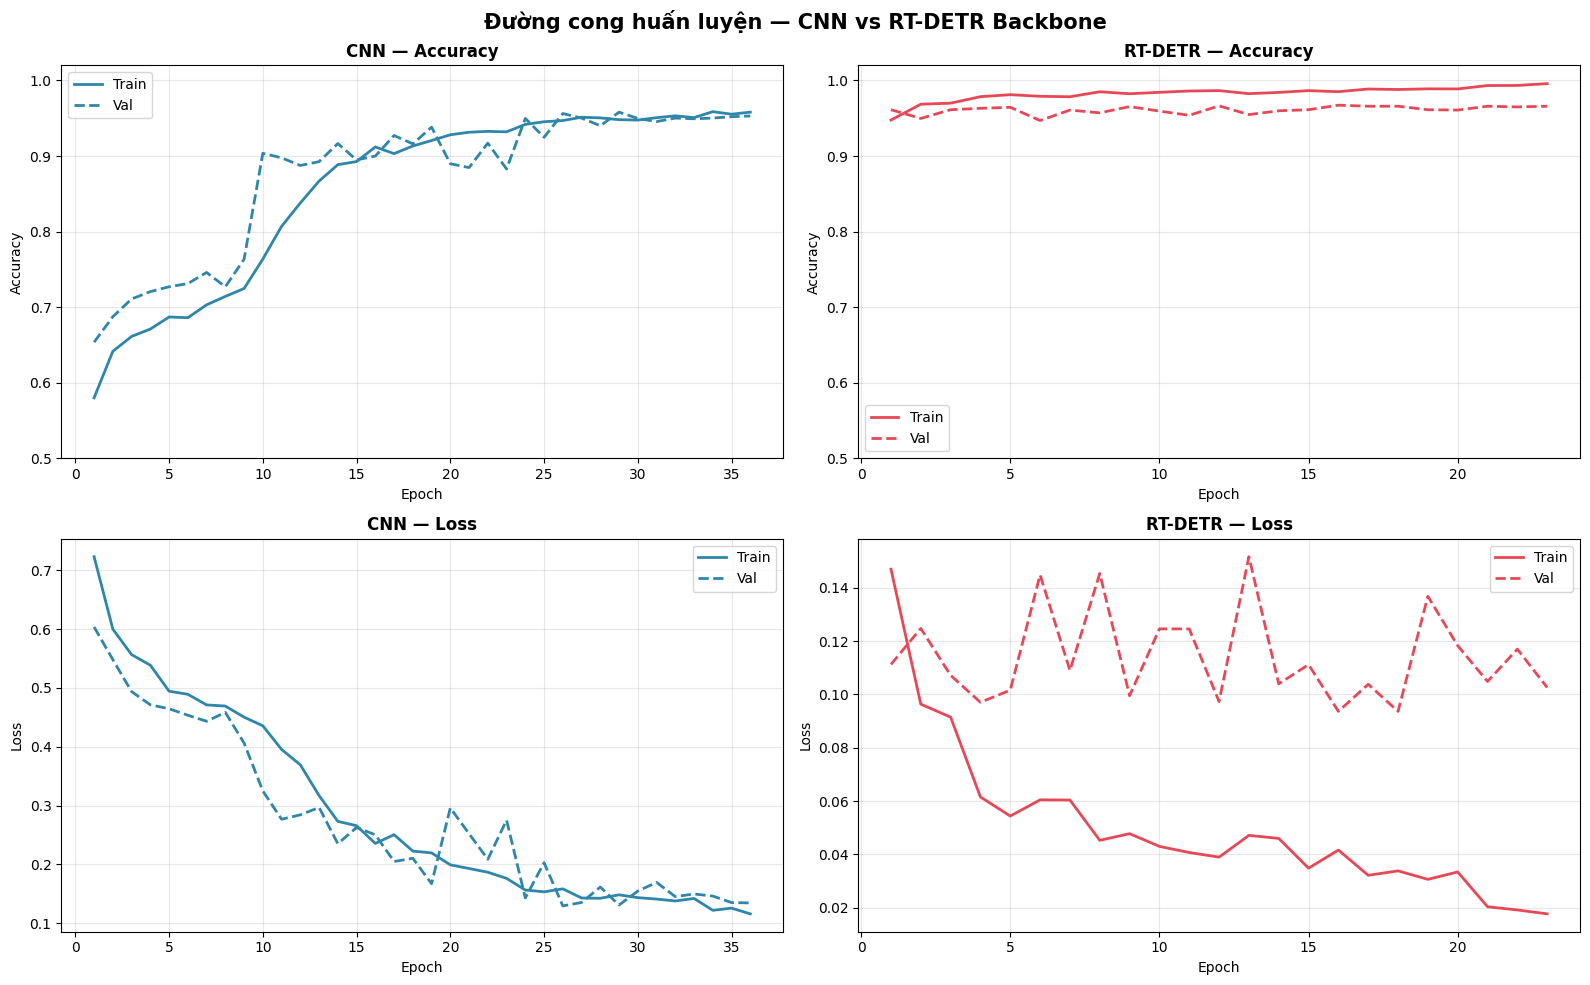

In [ ]:
# ═══════════════════════════════════════════════
# CELL 8 — Biểu đồ đường cong huấn luyện
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Đường cong huấn luyện — CNN vs RT-DETR Backbone',
             fontsize=15, fontweight='bold')

ep_cnn = range(1, len(hist_cnn['train_acc']) + 1)
ep_rt  = range(1, len(hist_rt['train_acc'])  + 1)

for ax, hist, ep, title, c in [
    (axes[0,0], hist_cnn, ep_cnn, 'CNN — Accuracy',         '#2E86AB'),
    (axes[0,1], hist_rt,  ep_rt,  'RT-DETR — Accuracy',     '#E84855'),
    ]:
    ax.plot(ep, hist['train_acc'], label='Train', color=c, lw=2)
    ax.plot(ep, hist['val_acc'],   label='Val',   color=c, lw=2, ls='--')
    ax.set_title(title, fontweight='bold'); ax.set_ylim(0.5, 1.02)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3)

for ax, hist, ep, title, c in [
    (axes[1,0], hist_cnn, ep_cnn, 'CNN — Loss',     '#2E86AB'),
    (axes[1,1], hist_rt,  ep_rt,  'RT-DETR — Loss', '#E84855'),
    ]:
    ax.plot(ep, hist['train_loss'], label='Train', color=c, lw=2)
    ax.plot(ep, hist['val_loss'],   label='Val',   color=c, lw=2, ls='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/chart_curves.png', dpi=150, bbox_inches='tight')
plt.show()

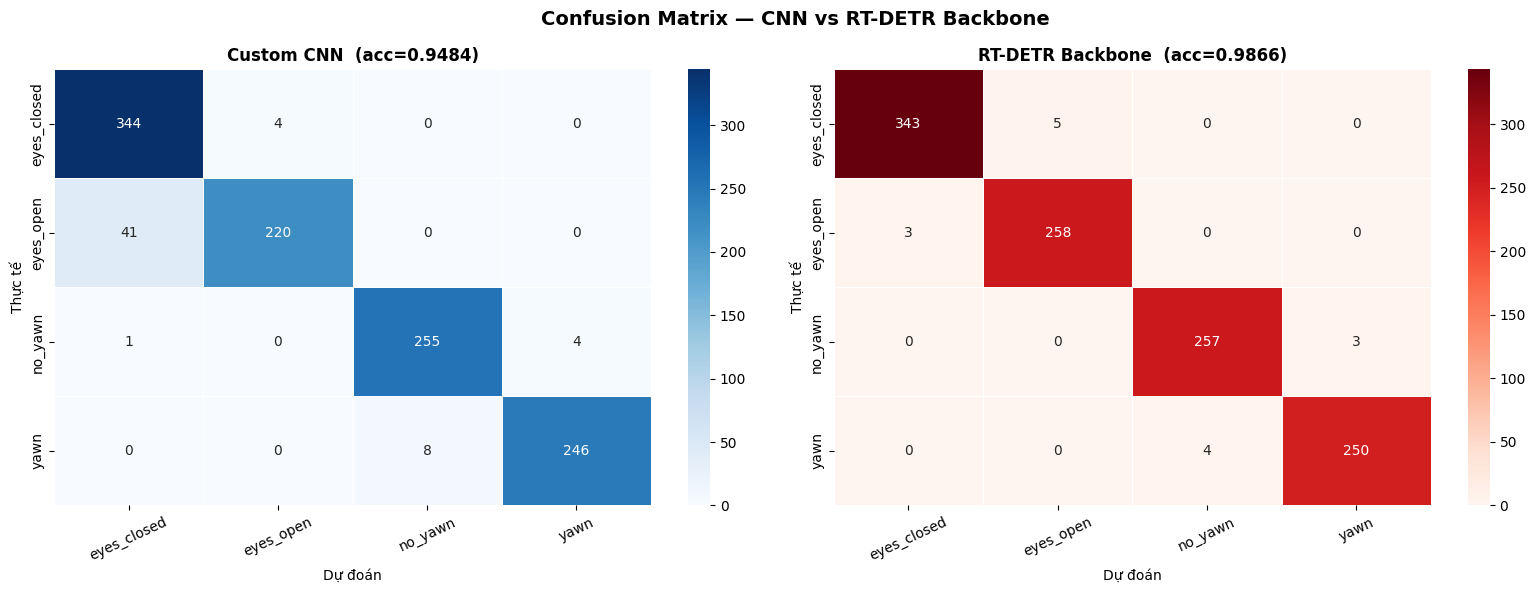

In [ ]:
# ═══════════════════════════════════════════════
# CELL 9 — Confusion Matrix song song
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — CNN vs RT-DETR Backbone',
             fontsize=14, fontweight='bold')

for ax, yt, yp, title, cmap in [
    (axes[0], y_true_cnn, y_pred_cnn, f'Custom CNN  (acc={acc_cnn:.4f})',        'Blues'),
    (axes[1], y_true_rt,  y_pred_rt,  f'RT-DETR Backbone  (acc={acc_rt:.4f})',   'Reds'),
]:
    sns.heatmap(confusion_matrix(yt, yp), annot=True, fmt='d',
                ax=ax, cmap=cmap, linewidths=0.5,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Dự đoán'); ax.set_ylabel('Thực tế')
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/chart_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

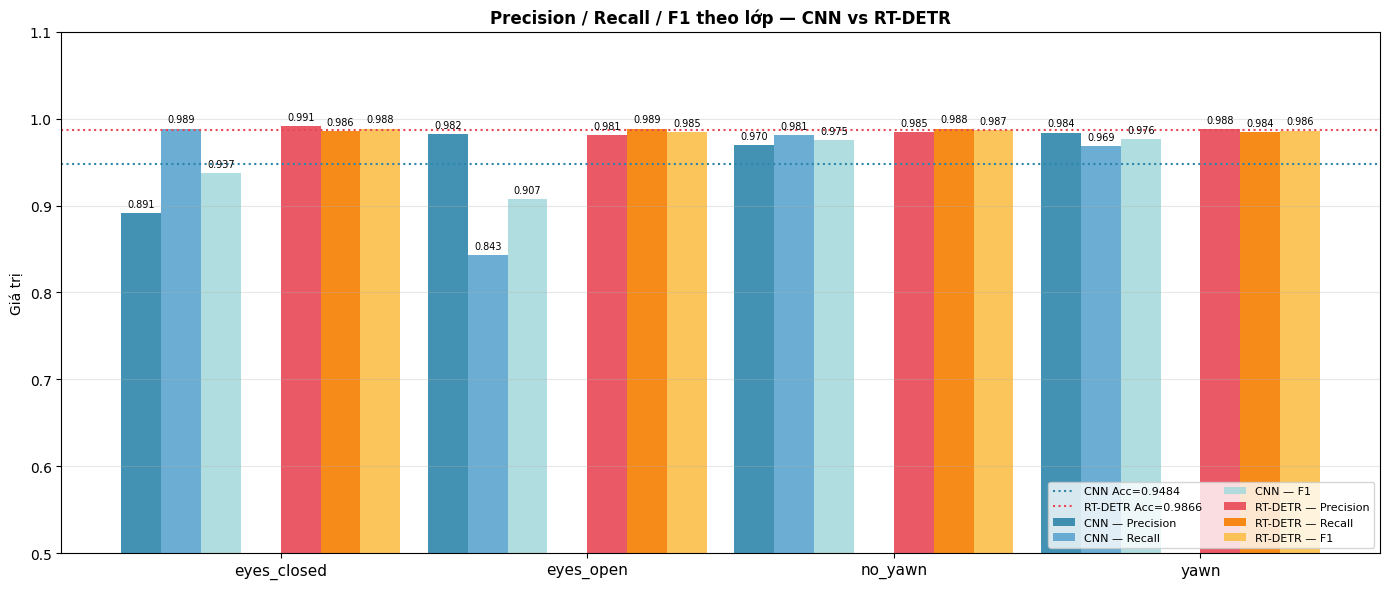

In [ ]:
# ═══════════════════════════════════════════════
# CELL 10 — Precision / Recall / F1 theo lớp
# ═══════════════════════════════════════════════
x  = np.arange(N_CLASSES)
w  = 0.13
fig, ax = plt.subplots(figsize=(14, 6))

specs = [
    (p_cnn,  -3.5*w, '#2E86AB', 'CNN — Precision'),
    (r_cnn,  -2.5*w, '#5BA4CF', 'CNN — Recall'),
    (f1_cnn, -1.5*w, '#A8DADC', 'CNN — F1'),
    (p_rt,    0.5*w, '#E84855', 'RT-DETR — Precision'),
    (r_rt,    1.5*w, '#F77F00', 'RT-DETR — Recall'),
    (f1_rt,   2.5*w, '#FCBF49', 'RT-DETR — F1'),
]
for vals, off, col, lbl in specs:
    bars = ax.bar(x + off, vals, width=w, color=col, label=lbl, alpha=0.9)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.axhline(acc_cnn, color='#2E86AB', lw=1.5, ls=':', label=f'CNN Acc={acc_cnn:.4f}')
ax.axhline(acc_rt,  color='#E84855', lw=1.5, ls=':', label=f'RT-DETR Acc={acc_rt:.4f}')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0.5, 1.1); ax.set_ylabel('Giá trị')
ax.set_title('Precision / Recall / F1 theo lớp — CNN vs RT-DETR', fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/chart_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_572/1337049589.py:54: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{SAVE_DIR}/chart_summary.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


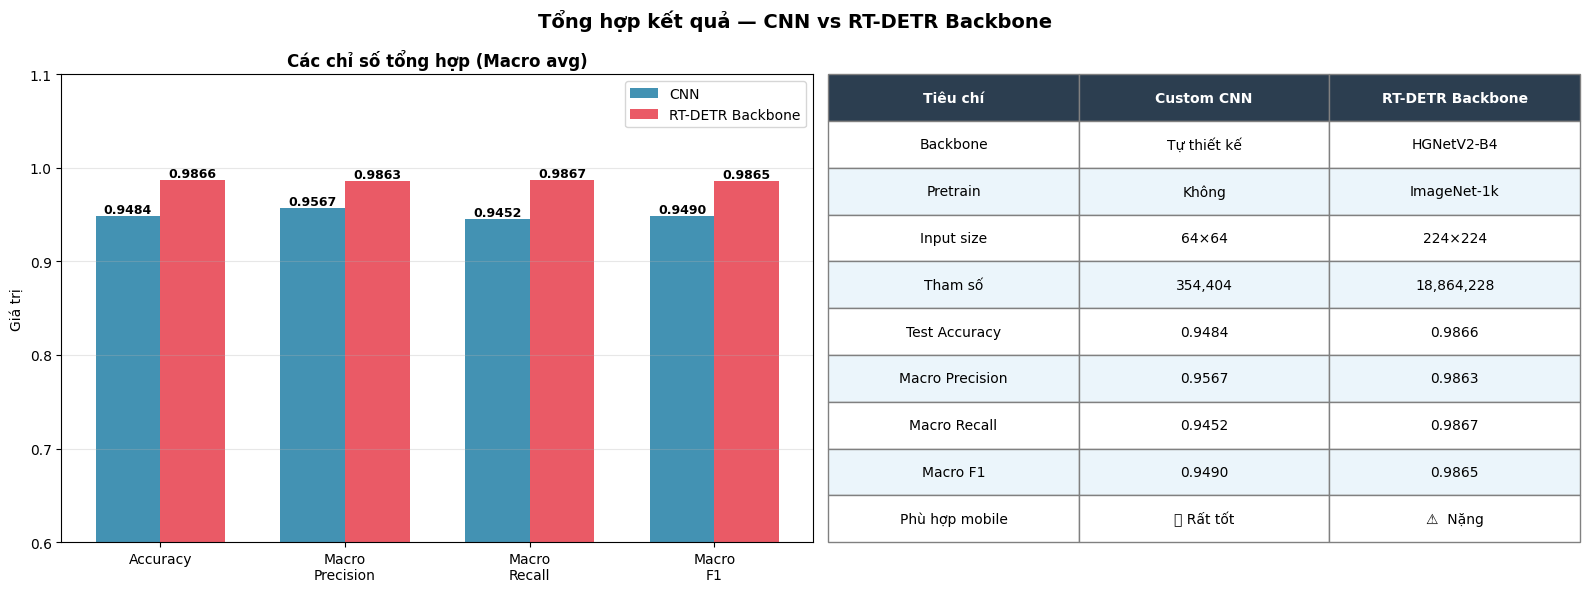

                                      CNN         RT-DETR
------------------------------------------------------------
Test Accuracy                      0.9484          0.9866
Macro Precision                    0.9567          0.9863
Macro Recall                       0.9452          0.9867
Macro F1                           0.9490          0.9865
Tham số                           354,404      18,864,228
Input size                          64×64         224×224

File lưu tại: /content/drive/MyDrive/models/compare


In [ ]:
# ═══════════════════════════════════════════════
# CELL 11 — Bảng tổng hợp + kết quả cuối
# ═══════════════════════════════════════════════
mp_cnn  = p_cnn.mean();  mr_cnn  = r_cnn.mean();  mf_cnn  = f1_cnn.mean()
mp_rt   = p_rt.mean();   mr_rt   = r_rt.mean();   mf_rt   = f1_rt.mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tổng hợp kết quả — CNN vs RT-DETR Backbone',
             fontsize=14, fontweight='bold')

# Biểu đồ cột tổng hợp
mn = ['Accuracy', 'Macro\nPrecision', 'Macro\nRecall', 'Macro\nF1']
vc = [acc_cnn, mp_cnn, mr_cnn, mf_cnn]
vr = [acc_rt,  mp_rt,  mr_rt,  mf_rt]
xx = np.arange(len(mn)); bw = 0.35
b1 = axes[0].bar(xx-bw/2, vc, bw, label='CNN',              color='#2E86AB', alpha=0.9)
b2 = axes[0].bar(xx+bw/2, vr, bw, label='RT-DETR Backbone', color='#E84855', alpha=0.9)
for bars in [b1, b2]:
    for b in bars:
        axes[0].annotate(f'{b.get_height():.4f}',
                         (b.get_x()+b.get_width()/2, b.get_height()),
                         ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xticks(xx); axes[0].set_xticklabels(mn, fontsize=10)
axes[0].set_ylim(0.6, 1.1); axes[0].set_ylabel('Giá trị')
axes[0].set_title('Các chỉ số tổng hợp (Macro avg)', fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(axis='y', alpha=0.3)

# Bảng so sánh
axes[1].axis('off')
rows = [
    ['Tiêu chí',        'Custom CNN',         'RT-DETR Backbone'],
    ['Backbone',         'Tự thiết kế',        'HGNetV2-B4'],
    ['Pretrain',         'Không',              'ImageNet-1k'],
    ['Input size',       '64×64',              '224×224'],
    ['Tham số',          f'{n_params_cnn:,}',  f'{n_params_rt:,}'],
    ['Test Accuracy',    f'{acc_cnn:.4f}',     f'{acc_rt:.4f}'],
    ['Macro Precision',  f'{mp_cnn:.4f}',      f'{mp_rt:.4f}'],
    ['Macro Recall',     f'{mr_cnn:.4f}',      f'{mr_rt:.4f}'],
    ['Macro F1',         f'{mf_cnn:.4f}',      f'{mf_rt:.4f}'],
    ['Phù hợp mobile',   '✅ Rất tốt',         '⚠️  Nặng'],
]
tbl = axes[1].table(cellText=rows[1:], colLabels=rows[0],
                    cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EBF5FB')
    cell.set_edgecolor('gray')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/chart_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# In kết quả text
print('='*60)
print(f'{"":25s} {"CNN":>15} {"RT-DETR":>15}')
print('-'*60)
for label, vc_, vr_ in [
    ('Test Accuracy',   acc_cnn,  acc_rt),
    ('Macro Precision', mp_cnn,   mp_rt),
    ('Macro Recall',    mr_cnn,   mr_rt),
    ('Macro F1',        mf_cnn,   mf_rt),
]:
    print(f'{label:25s} {vc_:>15.4f} {vr_:>15.4f}')
print('='*60)
print(f'{"Tham số":25s} {n_params_cnn:>15,} {n_params_rt:>15,}')
print(f'{"Input size":25s} {"64×64":>15} {"224×224":>15}')
print(f'\nFile lưu tại: {SAVE_DIR}')